## Preprocessing the data

### Importing Libraries

In [ ]:
!pip install neo4j

In [ ]:
# Basic Libraries for Data Manipulation
import pandas as pd
import numpy as np

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Libraries for Text Processing
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import regexp_tokenize
from nltk.stem import WordNetLemmatizer

# SpaCy for advanced text processing
import spacy
from spacy import displacy

# Libraries for Neo4j interaction
from neo4j import GraphDatabase

# Scikit-learn for machine learning tools (preprocessing)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer

# Miscellaneous Utilities
import string
import re

from transformers import BertTokenizer, BertModel
import torch
from tqdm import tqdm
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

# Setup for NLTK
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
df = pd.read_csv('arxiv_ai.csv')
df.head()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   authors           10000 non-null  object
 1   categories        10000 non-null  object
 2   comment           6136 non-null   object
 3   doi               1389 non-null   object
 4   entry_id          10000 non-null  object
 5   journal_ref       2028 non-null   object
 6   pdf_url           10000 non-null  object
 7   primary_category  10000 non-null  object
 8   published         10000 non-null  object
 9   summary           10000 non-null  object
 10  title             10000 non-null  object
 11  updated           10000 non-null  object
dtypes: object(12)
memory usage: 937.6+ KB


-------
### Dataset Description
This dataset contains metadata for 10,000 research papers in the field of Artificial Intelligence (AI) published on arXiv.org. The columns in your dataset are as follows:

1. **authors**: A list of authors (e.g., [arxiv.Result.Author('M. L. Ginsberg')]).
2. **categories**: A list of categories assigned to the paper (e.g., ['cs.AI']).
3. **comment**: Comments about the paper, often describing its presentation or publication context.
4. **doi**: The DOI (Digital Object Identifier) of the paper (or "No DOI available").
5. **entry_id**: The unique arXiv identifier for the paper (e.g., http://arxiv.org/abs/cs/9308101v1).
6. **journal_ref**: References to the journal where the paper may have been published.
7. **pdf_url**: Direct URL to the paper's PDF (e.g., http://arxiv.org/pdf/cs/9308101v1).
8. **primary_category**: The main category of the paper (e.g., cs.AI).
9. **published**: Date the paper was published, in datetime format (e.g., 1993-08-01 00:00:00+00:00).
10. **summary**: The abstract of the paper, providing a summary of its content.
11. **title**: The title of the paper.
12. **updated**: The date when the paper's record was last updated, in datetime format (e.g., 1993-08-01 00:00:00+00:00).
-------

### Handling missing values

In [ ]:
df.isnull().sum()

authors                0
categories             0
comment             3864
doi                 8611
entry_id               0
journal_ref         7972
pdf_url                0
primary_category       0
published              0
summary                0
title                  0
updated                0
dtype: int64

In [ ]:
zero_values = (df == 0).sum()
print(zero_values[zero_values > 0])

Series([], dtype: int64)


In [ ]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

print(missing_percentage[missing_percentage > 0])

comment        38.64
doi            86.11
journal_ref    79.72
dtype: float64


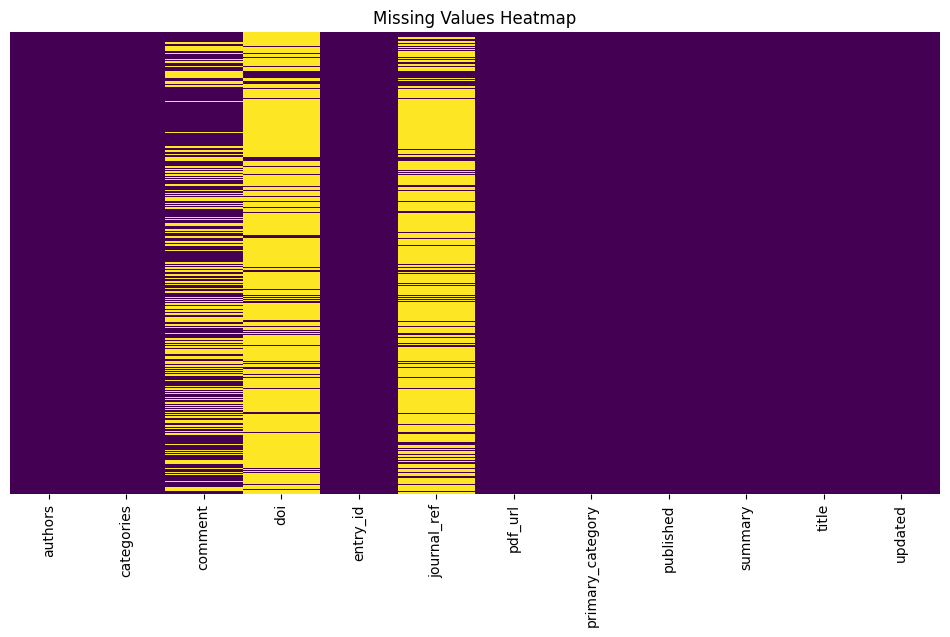

In [ ]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap')
plt.show()

In [ ]:
for col in ['comment', 'doi', 'journal_ref']:
    print(f"Unique values in '{col}':")
    print(df[col].nunique())
    print(df[col].unique())
    print("\n")

Unique values in 'comment':
4088
['See http://www.jair.org/ for an online appendix and other files\n  accompanying this article'
 'See http://www.jair.org/ for any accompanying files'
 '13 pages, European Conference on Planning 1997' ...
 'presented at the 4th World Congress on Social Simulation, Taipei,\n  September 2012'
 '2011 Fourth IEEE International Conference on Utility and Cloud\n  Computing (UCC)'
 'This work has been presented at the conference on Non-classical Modal\n  and Predicate Logics 2011, Guangzhou (Canton), China, 5-9 December 2011']


Unique values in 'doi':
1387
[nan '10.1613/jair.487' '10.1016/0167-2789(90)90087-6' ...
 '10.1145/1456223.1456281' '10.1109/UCC.2011.42'
 '10.1016/j.ijar.2015.05.009']


Unique values in 'journal_ref':
2010
['Journal of Artificial Intelligence Research, Vol 1, (1993), 25-46'
 'Journal of Artificial Intelligence Research, Vol 1, (1993), 1-23'
 'Journal of Artificial Intelligence Research, Vol 1, (1993), 47-59' ...
 'MTT - 5th Internatio

In [ ]:
df['comment'] = df['comment'].fillna('No comment available')

df['doi'] = df['doi'].fillna('No DOI available')

df['journal_ref'] = df['journal_ref'].fillna('No journal reference available')

print(df.isnull().sum())

authors             0
categories          0
comment             0
doi                 0
entry_id            0
journal_ref         0
pdf_url             0
primary_category    0
published           0
summary             0
title               0
updated             0
dtype: int64


In [ ]:
df['published'] = pd.to_datetime(df['published'], errors='coerce')

df['updated'] = pd.to_datetime(df['updated'], errors='coerce')

print(df[['published', 'updated']].head())

                  published                   updated
0 1993-08-01 00:00:00+00:00 1993-08-01 00:00:00+00:00
1 1993-08-01 00:00:00+00:00 1993-08-01 00:00:00+00:00
2 1993-09-01 00:00:00+00:00 1993-09-01 00:00:00+00:00
3 1993-11-01 00:00:00+00:00 1993-11-01 00:00:00+00:00
4 1993-11-01 00:00:00+00:00 1993-11-01 00:00:00+00:00


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   authors           10000 non-null  object             
 1   categories        10000 non-null  object             
 2   comment           10000 non-null  object             
 3   doi               10000 non-null  object             
 4   entry_id          10000 non-null  object             
 5   journal_ref       10000 non-null  object             
 6   pdf_url           10000 non-null  object             
 7   primary_category  10000 non-null  object             
 8   published         10000 non-null  datetime64[ns, UTC]
 9   summary           10000 non-null  object             
 10  title             10000 non-null  object             
 11  updated           10000 non-null  datetime64[ns, UTC]
dtypes: datetime64[ns, UTC](2), object(10)
memory usage: 937.6+ KB

-------
### Standardizing Author Names
The authors column currently appears as a list of arxiv.Result.Author objects. This format may not be directly usable for analysis or knowledge graph construction. We'll extract the names from these objects and represent them as a simple comma-separated string.

In [ ]:
def extract_authors(authors_list_str):
    # Extracting author names using regex and joining them as a comma-separated string
    author_pattern = r"arxiv\.Result\.Author\('([^']+)'\)"
    return ', '.join(re.findall(author_pattern, authors_list_str))

df['authors'] = df['authors'].apply(lambda x: extract_authors(x) if isinstance(x, str) else x)

print(df['authors'].head())

0                            M. L. Ginsberg
1                             M. P. Wellman
2                      I. P. Gent, T. Walsh
3    F. Bergadano, D. Gunetti, U. Trinchero
4            J. C. Schlimmer, L. A. Hermens
Name: authors, dtype: object


In [ ]:
# Adding a new column 'num_authors' which counts the number of authors in each paper
df['num_authors'] = df['authors'].apply(lambda x: len(x.split(',')))

In [ ]:
# Striping leading/trailing spaces and ensure consistent formatting
df['authors_normalized'] = df['authors'].apply(lambda x: [author.strip() for author in x.split(',')])

In [ ]:
# Getting the unique authors list
unique_authors = set([author for sublist in df['authors_normalized'] for author in sublist])
print(f"Number of unique authors: {len(unique_authors)}")

# Counting collaborations (e.g., pairs of authors who collaborate on the same paper)
from collections import Counter
collaborations = Counter()
for authors in df['authors_normalized']:
    for i in range(len(authors)):
        for j in range(i+1, len(authors)):
            collaboration_pair = tuple(sorted([authors[i], authors[j]]))
            collaborations[collaboration_pair] += 1

# Displaying some of the most common collaborations
print(collaborations.most_common(10))

Number of unique authors: 18629
[(('Didier Dubois', 'Henri Prade'), 21), (('Florentin Smarandache', 'Jean Dezert'), 20), (('Nina Narodytska', 'Toby Walsh'), 20), (('Sarath Sreedharan', 'Subbarao Kambhampati'), 20), (('Cameron Browne', 'Dennis J. N. J. Soemers'), 18), (('George Katsirelos', 'Toby Walsh'), 17), (('Blai Bonet', 'Hector Geffner'), 16), (('Ahmed Khalifa', 'Julian Togelius'), 15), (('George Katsirelos', 'Nina Narodytska'), 14), (('Julian Togelius', 'Michael Cerny Green'), 14)]


In [ ]:
df["authors_normalized"].head()

,authors_normalized
0,[M. L. Ginsberg]
1,[M. P. Wellman]
2,"[I. P. Gent, T. Walsh]"
3,"[F. Bergadano, D. Gunetti, U. Trinchero]"
4,"[J. C. Schlimmer, L. A. Hermens]"


-------
### Cleaning and Simplifying categories and primary_category.

1. The categories column often contains multiple categories (e.g., ['cs.AI', 'cs.CL']).
2. The primary_category column should ideally be a subset of categories.

In [ ]:
df['primary_category'].unique()

array(['cs.AI', 'cond-mat.dis-nn', 'cs.CC', 'cs.LO', 'cs.MA', 'cs.IR',
       'cs.RO', 'cs.DB', 'cs.LG', 'cs.CL', 'cs.PL', 'cs.DC', 'cs.PF',
       'cs.NE', 'cs.CE', 'cs.CG', 'cs.NI', 'cs.GT', 'cs.CV', 'cs.HC',
       'cs.CR', 'cs.OH', 'cs.SE', 'cs.DL', 'cs.MM', 'cs.DS', 'cs.DM',
       'cs.MS', 'cs.CY', 'math.LO', 'nlin.AO', 'q-bio.QM', 'quant-ph',
       'q-bio.NC', 'cs.GR', 'cs.SC', 'physics.data-an', 'stat.ML',
       'cs.AR', 'astro-ph.IM', 'math.CO', 'cs.FL', 'physics.soc-ph',
       'math.PR', 'cs.SY', 'math.OC', 'stat.ME', 'stat.CO', 'astro-ph.CO',
       'cs.SI', 'q-fin.RM'], dtype=object)

#### Cleaning categories
We will remove redundant characters and split subcategories.

In [ ]:
def clean_categories(categories_str):
    # Removing redundant quotes and brackets
    cleaned_str = re.sub(r"[\'\"\[\]]", "", categories_str)
    # Spliting semicolon-separated subcategories and returning a list
    return cleaned_str.split(', ')

df['categories_cleaned'] = df['categories'].apply(lambda x: clean_categories(x) if isinstance(x, str) else [])

print(df['categories_cleaned'].head())

0    [cs.AI]
1    [cs.AI]
2    [cs.AI]
3    [cs.AI]
4    [cs.AI]
Name: categories_cleaned, dtype: object


#### Handling Semicolon-Separated Subcategories
Subcategories like 'I.2.8; I.2.1; J.6' need to be separated and expanded.

In [ ]:
# Expanding semicolon-separated subcategories into a flat list
def expand_subcategories(category_list):
    expanded = []
    for cat in category_list:
        expanded.extend([sub.strip() for sub in cat.split(';')])
    return expanded

df['categories_expanded'] = df['categories_cleaned'].apply(expand_subcategories)

print(df['categories_expanded'].head())

0    [cs.AI]
1    [cs.AI]
2    [cs.AI]
3    [cs.AI]
4    [cs.AI]
Name: categories_expanded, dtype: object


#### Finding Unique Categories across All Lists
To get a flat list of all unique categories:

In [ ]:
unique_categories = set(cat for sublist in df['categories_expanded'] for cat in sublist)

print(f"Number of unique categories: {len(unique_categories)}")
print(unique_categories)

Number of unique categories: 495
{'', 'I.3.3', '68-06', '68Q05', 'I.2.10.f', 'H.3', 'research', '68R10', '03G25', 'I.1.2', '91F20', 'I.4.4', 'F4.3', '90C15 (Primary) 68T01 (Secondary)', 'F.3.3', '62A86', '68T30', '91A05', '91C20', '68R05', 'astro-ph.IM', 'H.1.m', 'cs.SI', 'H.0', '15B15', '68T05 (Primary)', 'I.2.3', '03B80', 'I2.8', '97C40', 'A.1', 'I 2.7', 'J.0', 'Artificial intelligence and nonmonotonic reasoning and belief\\n  revision', 'K.6.3', '62F15', 'cs.DC', 'cs.DB', 'I.2.2', 'K.3.2', 'I.5.3', 'I.5.4.b', '03B15', '05C85', 'I.3.6', '68N17', 'G.2.1', 'cs.DM', 'K.3.1', '91E40', 'F.2.2', 'H.5.2', 'G.3', '68T40 (Primary) 93C85 (Secondary)', '92B20', 'I.6.6', '94Axx', 'q-fin.GN', 'H.3.3', 'I2.4', 'F.4.q', 'H.4', '68Mxx,', 'q-fin.RM', '03A10', '68T01', 'K.6', '68W15', 'I.2.6', '90Cxx', '97Rxx', '68T35', 'cs.CC', 'I.1', '03B60', 'I.3', '03B70 (Primary) 68T27 (Secondary)', '03B42', 'G.1.7', '03-XX 03Cxx', 'math.LO', 'B.0', 'I.4.10', 'K.6.5', '03B52', 'D.1.7', '90C29', 'I.2.8', 'D.#.2', 

#### Finding Unique Combinations of Categories
The unique combinations of categories as they appear in categories_cleaned:

In [ ]:
# Converting lists to tuples and then find unique combinations
unique_combinations = df['categories_expanded'].apply(tuple).unique()

# Displaying unique combinations
print(f"Number of unique combinations: {len(unique_combinations)}")
print(unique_combinations[:5])

Number of unique combinations: 901
[('cs.AI',) ('cs.AI', 'I.2.8') ('cs.AI', 'I.1.2', 'I.2.2')
 ('cs.AI', 'I.2.0') ('cs.AI', 'I.2.8', 'I.2.1', 'J.6', 'I.2.4', 'F.2.2')]


#### Verifying primary_category Alignment
Ensuring that each primary_category is the first category in categories_cleaned.

In [ ]:
# Verifying if primary_category matches the first category in categories_cleaned
df['primary_category_valid'] = df.apply(lambda row: row['primary_category'] in row['categories_cleaned'], axis=1)

invalid_rows = df[~df['primary_category_valid']]
print(f"Number of invalid primary categories: {len(invalid_rows)}")
print(invalid_rows[['categories_cleaned', 'primary_category']].head())

Number of invalid primary categories: 0
Empty DataFrame
Columns: [categories_cleaned, primary_category]
Index: []


#### Inference
The output indicates that:

**"Number of invalid primary categories: 0"**
1. There are no rows where the primary_category is invalid.
2. This suggests that all primary_category values in the dataset are correctly aligned with the categories extracted from the categories_cleaned column.

**"Empty DataFrame Columns: [categories_cleaned, primary_category] Index: []"**
1. This implies that there are no mismatches or inconsistencies between the primary_category column and the first element of the categories_cleaned lists.
2. The dataset is clean in this aspect.

-------

### Extracting Key Information

In [ ]:
df["journal_ref"].nunique()

2011

In [ ]:
df["journal_ref"].unique()

array(['Journal of Artificial Intelligence Research, Vol 1, (1993), 25-46',
       'Journal of Artificial Intelligence Research, Vol 1, (1993), 1-23',
       'Journal of Artificial Intelligence Research, Vol 1, (1993), 47-59',
       ...,
       'MTT - 5th International Conference on Meaning-Text Theory - 2011\n  (2011) 155-164',
       'presented at the 4th World Congress on Social Simulation, Taipei,\n  September 2012',
       'Fourth IEEE International Conference on Utility and Cloud\n  Computing (UCC), 2011'],
      dtype=object)

In [ ]:
def extract_journal_info(journal):
    if pd.isna(journal):
        return {'journal_name': None, 'year': None, 'volume': None, 'pages': None}

    # Regex patterns for extracting components
    year_pattern = r'\b(19|20)\d{2}\b'  # Matching years (1900-2099)
    volume_pattern = r'Vol\s*(\d+)'  # Matching "Vol <number>"
    pages_pattern = r'(\d+-\d+)'  # Matching page ranges like "25-46"
    journal_name_pattern = r'^(.*?)(?:,|Vol|[\n\(])'  # Extracting journal name before other markers

    # Extracting data
    journal_name = re.search(journal_name_pattern, journal)
    year = re.search(year_pattern, journal)
    volume = re.search(volume_pattern, journal)
    pages = re.search(pages_pattern, journal)

    return {
        'journal_name': journal_name.group(1).strip() if journal_name else None,
        'year': int(year.group(0)) if year else None,
        'volume': int(volume.group(1)) if volume else None,
        'pages': pages.group(1) if pages else None
    }

df_journal_info = df['journal_ref'].apply(extract_journal_info).apply(pd.Series)

df = pd.concat([df, df_journal_info], axis=1)

print("Extracted journal information columns:")
print(df[['journal_ref', 'journal_name', 'year', 'volume', 'pages']].head())

Extracted journal information columns:
                                         journal_ref  \
0  Journal of Artificial Intelligence Research, V...   
1  Journal of Artificial Intelligence Research, V...   
2  Journal of Artificial Intelligence Research, V...   
3  Journal of Artificial Intelligence Research, V...   
4  Journal of Artificial Intelligence Research, V...   

                                  journal_name    year  volume   pages  
0  Journal of Artificial Intelligence Research  1993.0     1.0   25-46  
1  Journal of Artificial Intelligence Research  1993.0     1.0    1-23  
2  Journal of Artificial Intelligence Research  1993.0     1.0   47-59  
3  Journal of Artificial Intelligence Research  1993.0     1.0  91-107  
4  Journal of Artificial Intelligence Research  1993.0     1.0   61-89  


In [ ]:
df['journal_name'] = df['journal_name'].fillna("Unknown Journal")
df['year'] = df['year'].fillna(0)
df['volume'] = df['volume'].fillna(0)
df['pages'] = df['pages'].fillna("Unknown Pages")

print(df[['journal_name', 'year', 'volume', 'pages']].isnull().sum())

journal_name    0
year            0
volume          0
pages           0
dtype: int64


#### Explanation
1. Key Information Extraction:
    - Journal Name: The name of the journal is extracted as the first part of the string (up to a comma, volume, or parentheses).
    - Year: A 4-digit year is extracted using a regex pattern.
    - Volume: Matches "Vol <number>".
    - Pages: Captures page ranges in the format 25-46.

2. Create a Structured Format:
    - The extracted information is returned as a dictionary and converted into a new DataFrame.
    - This structured data is appended back to the original DataFrame for further use.

3. Validation:
    - A sample of the original and extracted values is printed for verification.

-------

### Title Preprocessing

1. Ensuring consistency in format (e.g., uniform case).
2. Removing leading/trailing whitespace.
3. Standardizing special characters if needed (e.g., replacing dashes with spaces).
4. Checking for duplicates post-cleaning (though titles are unique, preprocessing might introduce unintentional duplication).

In [ ]:
df["title"].nunique()

9980

In [ ]:
df["title"].unique()

array(['Dynamic Backtracking',
       'A Market-Oriented Programming Environment and its Application to Distributed Multicommodity Flow Problems',
       'An Empirical Analysis of Search in GSAT', ...,
       'Intelligent Automated Diagnosis of Client Device Bottlenecks in Private Clouds',
       'On the Complexity of Finding Second-Best Abductive Explanations',
       'Quantified Conditional Logics are Fragments of HOL'], dtype=object)

In [ ]:
def clean_title(title):
    if pd.isna(title):
        return None

    # Striping leading/trailing whitespace
    title = title.strip()

    # Normalizing to title case
    title = title.title()

    # Replacing unusual dashes/hyphens with standard space
    title = title.replace('–', '-').replace('—', '-')

    # Normalizing multiple spaces
    title = ' '.join(title.split())

    return title

# Applying the cleaning function
df['cleaned_title'] = df['title'].apply(clean_title)

# Verifying the cleaning
print("Original and Cleaned Titles:")
print(df[['title', 'cleaned_title']].head())

Original and Cleaned Titles:
                                               title  \
0                               Dynamic Backtracking   
1  A Market-Oriented Programming Environment and ...   
2            An Empirical Analysis of Search in GSAT   
3  The Difficulties of Learning Logic Programs wi...   
4  Software Agents: Completing Patterns and Const...   

                                       cleaned_title  
0                               Dynamic Backtracking  
1  A Market-Oriented Programming Environment And ...  
2            An Empirical Analysis Of Search In Gsat  
3  The Difficulties Of Learning Logic Programs Wi...  
4  Software Agents: Completing Patterns And Const...  


-------

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype              
---  ------                  --------------  -----              
 0   authors                 10000 non-null  object             
 1   categories              10000 non-null  object             
 2   comment                 10000 non-null  object             
 3   doi                     10000 non-null  object             
 4   entry_id                10000 non-null  object             
 5   journal_ref             10000 non-null  object             
 6   pdf_url                 10000 non-null  object             
 7   primary_category        10000 non-null  object             
 8   published               10000 non-null  datetime64[ns, UTC]
 9   summary                 10000 non-null  object             
 10  title                   10000 non-null  object             
 11  updated                 10000 non-null  da

-------
### Published and Updated columns

In [ ]:
df['published_year'] = df['published'].dt.year
df['published_month'] = df['published'].dt.month
df['published_day'] = df['published'].dt.day
df['updated_year'] = df['updated'].dt.year
df['updated_month'] = df['updated'].dt.month
df['updated_day'] = df['updated'].dt.day

-------
### Preprocessing the comment column

In [ ]:
df['comment'].nunique()

4089

In [ ]:
df['comment'].unique()

array(['See http://www.jair.org/ for an online appendix and other files\n  accompanying this article',
       'See http://www.jair.org/ for any accompanying files',
       '13 pages, European Conference on Planning 1997', ...,
       'presented at the 4th World Congress on Social Simulation, Taipei,\n  September 2012',
       '2011 Fourth IEEE International Conference on Utility and Cloud\n  Computing (UCC)',
       'This work has been presented at the conference on Non-classical Modal\n  and Predicate Logics 2011, Guangzhou (Canton), China, 5-9 December 2011'],
      dtype=object)

In [ ]:
def clean_comment(comment):
    # Removing URLs using a regular expression
    comment = re.sub(r'http\S+', ' ', comment)  # Removing URLs

    # Removing newlines and extra spaces
    comment = comment.replace('\n', ' ').replace('\r', ' ')

    # Removing unwanted patterns, e.g., conference or event details that are non-informative
    comment = re.sub(r'\d{4}.*(Conference|Workshop|Presented|at|in|Vol).*', ' ', comment)

    # Converting text to lowercase
    comment = comment.lower()

    # Removing any remaining non-alphabetical characters (except spaces)
    comment = re.sub(r'[^a-zA-Z\s]', '', comment)

    # Striping any leading or trailing whitespaces
    comment = comment.strip()

    return comment

# Applying the cleaning function to the 'comment' column
df['comment_cleaned'] = df['comment'].apply(clean_comment)

In [ ]:
def further_clean_comment(comment):
    # Removing any extra spaces (multiple spaces) between words
    comment = re.sub(r'\s+', ' ', comment)

    # Triming leading and trailing spaces
    comment = comment.strip()

    return comment

df['comment_cleaned'] = df['comment_cleaned'].apply(further_clean_comment)

1. Tokenization:
    - Tokenizing your title and summary columns splits the text into words or phrases, which are more manageable for analysis. It also helps in identifying individual entities or keywords that can be further processed.

2. Stemming:
    - Stemming reduces words to their root forms. For example, "running" becomes "run." It's a simpler process and can be faster, but it can sometimes be overly aggressive and reduce words in a way that changes their meaning.

3. Lemmatization:
    - Lemmatization also reduces words to their base form (like "better" to "good"), but it takes into account the context and is more accurate. It's generally preferred over stemming for tasks where the meaning of the word is important.

#### Tokenization of Text Data

In [ ]:
# Tokenizing the 'comment_cleaned' column
df['comment_tokens'] = df['comment_cleaned'].apply(word_tokenize)
df['comment_tokens'].head()

,comment_tokens
0,"[see, for, an, online, appendix, and, other, f..."
1,"[see, for, any, accompanying, files]"
2,"[see, for, any, accompanying, files]"
3,"[see, for, any, accompanying, files]"
4,"[see, for, an, online, appendix, and, other, f..."


In [ ]:
stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    return [word for word in tokens if word.lower() not in stop_words]

df['comment_tokens'] = df['comment_tokens'].apply(remove_stopwords)
df['comment_tokens'].head()

,comment_tokens
0,"[see, online, appendix, files, accompanying, a..."
1,"[see, accompanying, files]"
2,"[see, accompanying, files]"
3,"[see, accompanying, files]"
4,"[see, online, appendix, files, accompanying, a..."


#### Stemming

In [ ]:
stemmer = PorterStemmer()

def apply_stemming(tokens):
    return [stemmer.stem(word) for word in tokens]

df['comment_tokens'] = df['comment_tokens'].apply(apply_stemming)

#### Lemmatization

In [ ]:
lemmatizer = WordNetLemmatizer()

def apply_lemmatization(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

df['comment_tokens'] = df['comment_tokens'].apply(apply_lemmatization)
df['comment_tokens'].head()

,comment_tokens
0,"[see, for, an, onlin, appendix, and, other, fi..."
1,"[see, for, ani, accompani, file]"
2,"[see, for, ani, accompani, file]"
3,"[see, for, ani, accompani, file]"
4,"[see, for, an, onlin, appendix, and, other, fi..."


-------
### Exploratory Data Analysis (EDA)

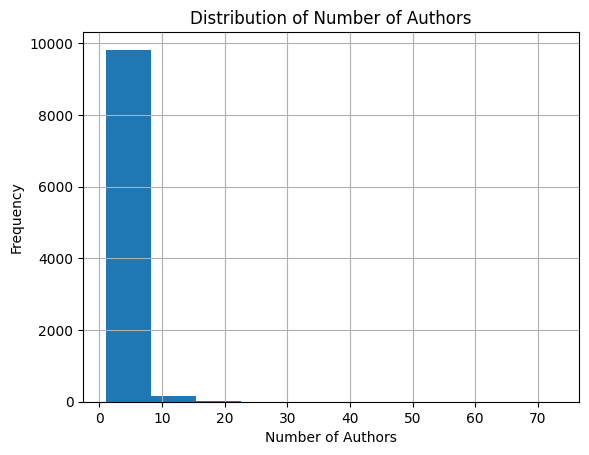

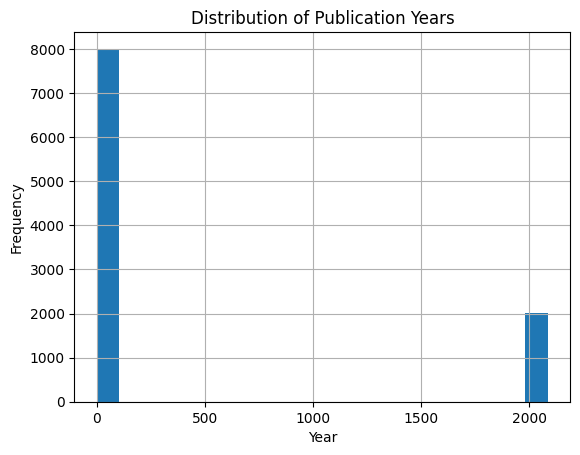

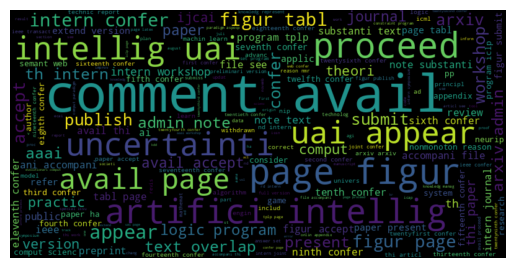

In [ ]:
df['num_authors'].hist()
plt.title('Distribution of Number of Authors')
plt.xlabel('Number of Authors')
plt.ylabel('Frequency')
plt.show()

df['year'].hist(bins=20)
plt.title('Distribution of Publication Years')
plt.xlabel('Year')
plt.ylabel('Frequency')
plt.show()

from wordcloud import WordCloud
all_tokens = ' '.join([' '.join(tokens) for tokens in df['comment_tokens']])
wordcloud = WordCloud(width=800, height=400).generate(all_tokens)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

### Feature Engineering

In [ ]:
df['comment_length'] = df['comment_cleaned'].apply(len)

df['num_comment_tokens'] = df['comment_tokens'].apply(len)

# Sentiment Analysis using TextBlob
from textblob import TextBlob
df['comment_sentiment'] = df['comment_cleaned'].apply(lambda x: TextBlob(x).sentiment.polarity)

df[['comment_length', 'num_comment_tokens', 'comment_sentiment']].head()

,comment_length,num_comment_tokens,comment_sentiment
0,68,11,-0.125
1,30,5,0.000
2,30,5,0.000
3,30,5,0.000
4,68,11,-0.125


In [ ]:
df['title_tokens'] = df['title'].apply(lambda x: word_tokenize(x.lower()))
df['summary_tokens'] = df['summary'].apply(lambda x: word_tokenize(x.lower()))

In [ ]:
stemmer = PorterStemmer()
df['title_tokens'] = df['title_tokens'].apply(lambda x: [stemmer.stem(word) for word in x])
df['summary_tokens'] = df['summary_tokens'].apply(lambda x: [stemmer.stem(word) for word in x])

In [ ]:
lemmatizer = WordNetLemmatizer()
df['title_tokens'] = df['title_tokens'].apply(lambda x: [lemmatizer.lemmatize(word) for word in x])
df['summary_tokens'] = df['summary_tokens'].apply(lambda x: [lemmatizer.lemmatize(word) for word in x])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 35 columns):
 #   Column                  Non-Null Count  Dtype              
---  ------                  --------------  -----              
 0   authors                 10000 non-null  object             
 1   categories              10000 non-null  object             
 2   comment                 10000 non-null  object             
 3   doi                     10000 non-null  object             
 4   entry_id                10000 non-null  object             
 5   journal_ref             10000 non-null  object             
 6   pdf_url                 10000 non-null  object             
 7   primary_category        10000 non-null  object             
 8   published               10000 non-null  datetime64[ns, UTC]
 9   summary                 10000 non-null  object             
 10  title                   10000 non-null  object             
 11  updated                 10000 non-null  da

### Using BERT for Contextual Embeddings

In [ ]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

def get_bert_embeddings_batch(texts, tokenizer, model, batch_size=16):
    embeddings = []

    # Batching the texts
    for i in tqdm(range(0, len(texts), batch_size)):
        batch_texts = texts[i:i+batch_size]

        encodings = tokenizer(batch_texts, padding=True, truncation=True, return_tensors='pt', max_length=512)
        encodings = {key: value.to(device) for key, value in encodings.items()}

        with torch.no_grad():
            outputs = model(**encodings)
            last_hidden_states = outputs.last_hidden_state

        batch_embeddings = last_hidden_states.mean(dim=1).cpu().numpy()
        embeddings.extend(batch_embeddings)

    return np.array(embeddings)

title_embeddings = get_bert_embeddings_batch(df['title_tokens'].apply(lambda x: ' '.join(x)).tolist(), tokenizer, model)
summary_embeddings = get_bert_embeddings_batch(df['summary_tokens'].apply(lambda x: ' '.join(x)).tolist(), tokenizer, model)
comment_embeddings = get_bert_embeddings_batch(df['comment_tokens'].apply(lambda x: ' '.join(x)).tolist(), tokenizer, model)

title_df = pd.DataFrame(title_embeddings)
summary_df = pd.DataFrame(summary_embeddings)
comment_df = pd.DataFrame(comment_embeddings)

df['title_bert_embeddings'] = title_df.values.tolist()
df['summary_bert_embeddings'] = summary_df.values.tolist()
df['comment_bert_embeddings'] = comment_df.values.tolist()

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

100%|██████████| 625/625 [00:19<00:00, 31.94it/s]


In [ ]:
df.to_csv('bert_embeddings_with_metadata.csv', index=False)
print("DataFrame with BERT embeddings saved as 'bert_embeddings_with_metadata.csv'")

DataFrame with BERT embeddings saved as 'bert_embeddings_with_metadata.csv'


### Saving the data in a csv file

In [ ]:
tokenizer.save_pretrained('./bert_tokenizer')
model.save_pretrained('./bert_model')
print("BERT model and tokenizer saved locally.")

BERT model and tokenizer saved locally.


In [ ]:
b = pd.read_csv('bert_embeddings_with_metadata.csv')

### Formatting the pages column correctly

In [ ]:
month_map = {
    'Jan': '1', 'Feb': '2', 'Mar': '3', 'Apr': '4',
    'May': '5', 'Jun': '6', 'Jul': '7', 'Aug': '8',
    'Sep': '9', 'Oct': '10', 'Nov': '11', 'Dec': '12'
}

def correct_pages_format(value):
    for month, num in month_map.items():
        if re.search(rf'\b{month}\b', value):
            corrected_value = re.sub(rf'\b{month}\b', num, value)
            return corrected_value
    return value

b['pages'] = b['pages'].astype(str).apply(correct_pages_format)

b.to_csv('bert_embeddings_with_metadata.csv', index=False)
print("Pages column corrected and changes saved to 'bert_embeddings_with_metadata.csv'.")

Pages column corrected and changes saved to 'bert_embeddings_with_metadata.csv'.


In [ ]:
def compute_number_of_pages(pages):
    try:
        page_range = pages.split('-')
        if len(page_range) == 2:
            return abs(int(page_range[1]) - int(page_range[0])) + 1
        else:
            return 1
    except Exception:
        return 0

b['num_pages'] = b['pages'].apply(compute_number_of_pages)

b.to_csv('bert_embeddings_with_metadata.csv', index=False)
print("Number of pages computed and added to the original file.")

Number of pages computed and added to the original file.


### Filtering the important and the most relevant columns to build a prototype in Neo4j

> Add blockquote



In [ ]:
filtered_columns = [
    'authors', 'num_authors',
    'categories_expanded', 'primary_category',
    'comment', 'comment_tokens', 'comment_length', 'comment_sentiment',
    'doi', 'entry_id',
    'journal_name', 'year', 'published_year', 'updated_year', 'num_pages',
    'summary', 'summary_tokens',
    'title', 'cleaned_title', 'title_tokens',
    'title_bert_embeddings', 'summary_bert_embeddings', 'comment_bert_embeddings'
]

filtered_data = b[filtered_columns]

filtered_data.to_csv('filtered_data.csv', index=False)
print("Filtered data saved as 'filtered_data.csv'.")

Filtered data saved as 'filtered_data.csv'.


In [ ]:
f = pd.read_csv('filtered_data.csv')
f.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   authors                  9990 non-null   object 
 1   num_authors              10000 non-null  int64  
 2   categories_expanded      10000 non-null  object 
 3   primary_category         10000 non-null  object 
 4   comment                  10000 non-null  object 
 5   comment_tokens           10000 non-null  object 
 6   comment_length           10000 non-null  int64  
 7   comment_sentiment        10000 non-null  float64
 8   doi                      10000 non-null  object 
 9   entry_id                 10000 non-null  object 
 10  journal_name             9991 non-null   object 
 11  year                     10000 non-null  float64
 12  published_year           10000 non-null  int64  
 13  updated_year             10000 non-null  int64  
 14  num_pages              

### Cleaning the filtered data for importing it in Neo4j

In [ ]:
def fix_malformed_quotes(text):
    if isinstance(text, str):
        text = text.replace('""', '"')
        if text.count('"') % 2 != 0:
            text = text + '"'
    return text

f = f.applymap(fix_malformed_quotes)

f.to_csv('filtered_data.csv', index=False)

print("CSV file has been cleaned and saved.")

C:\Users\Sri Lakshmi\AppData\Local\Temp\ipykernel_14648\1200470210.py:8: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  f = f.applymap(fix_malformed_quotes)


CSV file has been cleaned and saved.


In [ ]:
import csv

def clean_text_field(text):
    if isinstance(text, str):
        text = text.replace('"', '""')
        text = text.replace('\n', ' ').replace('\r', '')
    return text

input_file = 'filtered_data.csv'
output_file = 'cleaned_filtered_data.csv'

with open(input_file, mode='r', encoding='utf-8') as infile:
    reader = csv.DictReader(infile)
    fieldnames = reader.fieldnames

    with open(output_file, mode='w', newline='', encoding='utf-8') as outfile:
        writer = csv.DictWriter(outfile, fieldnames=fieldnames)
        writer.writeheader()

        for row in reader:
            # Clean each field in the row
            for field in fieldnames:
                row[field] = clean_text_field(row[field])
            writer.writerow(row)

print(f"File cleaned and saved to {output_file}")

File cleaned and saved to cleaned_filtered_data.csv


In [ ]:
with open('cleaned_filtered_data.csv', mode='r', newline='', encoding='utf-8') as file:
    reader = csv.reader(file)

    for line_num, row in enumerate(reader, start=1):
        try:
            for field in row:
                if field.count('"') % 2 != 0:
                    print(f"Problematic field in row {line_num}: {row}")
                    break
        except Exception as e:
            print(f"Error in line {line_num}: {e}")

In [ ]:
with open('cleaned_filtered_data.csv', 'rb') as file:
    file.seek(162249622)  # Seek to the specific byte position
    content = file.read(100)  # Read a chunk around that position for context
    print(content)  # Print out the byte content around the error position

b'-0.34473827481269836, 0.16372109949588776, -0.23940739035606384, -0.19899770617485046, -0.2026458084'


In [ ]:
problematic_string = "-0.34473827481269836, 0.16372109949588776, -0.23940739035606384, -0.19899770617485046, -0.2026458084"

with open('cleaned_filtered_data.csv', mode='r', encoding='utf-8') as file:
    # Read through the file line by line
    for line_num, line in enumerate(file, start=1):
        if problematic_string in line:
            print(f"Found in line {line_num}: {line}")
            break  # Exit after finding the first match

Found in line 3282: Francesc Serratosa,1,cs.AI,No comment available,20,0.4,No DOI available,http://arxiv.org/abs/1605.02929v1,Unknown Journal,0,2016,2016,1,Function-Described Graphs For Structural Pattern Recognition,"[-0.34722352027893066, -0.6478046774864197, 0.3053133487701416, 0.023620259016752243, 0.19629795849323273, 0.21109141409397125, 0.005972764920443296, 0.010197930969297886, 0.06267620623111725, -0.5737324953079224, -0.06116693839430809, 0.03440428525209427, -0.04516713321208954, 0.25950905680656433, -0.021659323945641518, 0.37097734212875366, -0.09911053627729416, 0.06937573850154877, 0.17405757308006287, -0.05318427085876465, 0.44426459074020386, -0.03711468726396561, -0.45802217721939087, 0.03510824963450432, 0.4907679259777069, -0.01578364148736, -0.07318799942731857, 0.15395504236221313, -0.624448299407959, 0.20839649438858032, -0.23510226607322693, 0.4035208523273468, -0.07090973109006882, -0.17631971836090088, -0.15682527422904968, -0.28344979882240295, 0.00554278586

In [ ]:
input_file = 'cleaned_filtered_data.csv'
output_file = 'cleaned_filtered_data_fixed.csv'

with open(input_file, 'r', encoding='utf-8') as infile, open(output_file, 'w', encoding='utf-8', newline='') as outfile:
    reader = csv.reader(infile)
    writer = csv.writer(outfile)

    for row in reader:
        cleaned_row = []
        for field in row:
            cleaned_field = field.replace('"""', '"')
            cleaned_field = cleaned_field.replace("'", "''")
            cleaned_row.append(cleaned_field)

        writer.writerow(cleaned_row)

print("CSV file cleaned and saved to:", output_file)

CSV file cleaned and saved to: cleaned_filtered_data_fixed.csv


In [ ]:
c = pd.read_csv('cleaned_filtered_data_fixed.csv')
c.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   authors                  9990 non-null   object 
 1   num_authors              10000 non-null  int64  
 2   categories_expanded      10000 non-null  object 
 3   primary_category         10000 non-null  object 
 4   comment                  10000 non-null  object 
 5   comment_tokens           10000 non-null  object 
 6   comment_length           10000 non-null  int64  
 7   comment_sentiment        10000 non-null  float64
 8   doi                      10000 non-null  object 
 9   entry_id                 10000 non-null  object 
 10  journal_name             9991 non-null   object 
 11  year                     10000 non-null  float64
 12  published_year           10000 non-null  int64  
 13  updated_year             10000 non-null  int64  
 14  num_pages              

In [ ]:
c['authors'] = c['authors'].fillna('Author Unknown')

c['journal_name'] = c['journal_name'].fillna('Journal Unknown')

In [ ]:
c.to_csv('cleaned_filtered_data_fixed.csv', index=False)

In [ ]:
columns_to_convert = ['num_authors', 'comment_length', 'comment_sentiment',
                      'year', 'published_year', 'updated_year', 'num_pages']

for col in columns_to_convert:
    c[col] = pd.to_numeric(c[col], errors='coerce')

In [ ]:
columns_to_convert = ['authors', 'comment_length', 'comment_sentiment',
                      'doi', 'entry_id', 'journal_name', 'cleaned_title',
                      'title_bert_embeddings', 'summary_bert_embeddings',
                      'comment_bert_embeddings']

for col in columns_to_convert:
    c[col] = c[col].astype(str)

In [ ]:
c = c.fillna('')

In [ ]:
print(c.dtypes)

authors                    object
num_authors                 int64
primary_category           object
comment                    object
comment_length             object
comment_sentiment          object
doi                        object
entry_id                   object
journal_name               object
year                        int64
published_year              int64
updated_year                int64
num_pages                   int64
cleaned_title              object
title_bert_embeddings      object
summary_bert_embeddings    object
comment_bert_embeddings    object
dtype: object


In [ ]:
cleaned_lines = []
with open("cleaned_filtered_data_fixed.csv", "r") as file:
    for line in file:
        if line.count('"') % 2 == 0:  # Keep lines with balanced quotes
            cleaned_lines.append(line)

with open("cleaned_filtered_data_fixed_cleaned.csv", "w") as file:
    file.writelines(cleaned_lines)

### Implementation of Semantic Search using BERT

In [ ]:
df = pd.read_csv("cleaned_filtered_data_fixed_cleaned.csv", on_bad_lines="skip")

In [ ]:
# Step 1: Parsing the title_bert_embeddings into numpy arrays
df["title_bert_embeddings"] = df["title_bert_embeddings"].apply(eval)
df["title_bert_embeddings"] = df["title_bert_embeddings"].apply(np.array)

# Step 2: Load a pre-trained SentenceTransformer model for query embedding
model = SentenceTransformer("bert-base-nli-mean-tokens")

# Step 3: Semantic Search Function
def semantic_search(query, top_n=5):
    # Embed the query
    query_embedding = model.encode([query])

    # Compute cosine similarity with all document embeddings
    document_embeddings = np.vstack(df["title_bert_embeddings"].values)
    similarities = cosine_similarity(query_embedding, document_embeddings).flatten()

    # Get the indices of the top N most similar documents
    top_indices = np.argsort(similarities)[::-1][:top_n]

    # Retrieve the matching rows and their similarity scores
    results = df.iloc[top_indices].copy()
    results["similarity_score"] = similarities[top_indices]

    return results

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.99k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

1_Pooling/config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255 entries, 0 to 254
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   authors                  254 non-null    object 
 1   num_authors              255 non-null    int64  
 2   primary_category         255 non-null    object 
 3   comment                  255 non-null    object 
 4   comment_length           255 non-null    int64  
 5   comment_sentiment        255 non-null    float64
 6   doi                      255 non-null    object 
 7   entry_id                 255 non-null    object 
 8   journal_name             255 non-null    object 
 9   year                     255 non-null    int64  
 10  published_year           255 non-null    int64  
 11  updated_year             255 non-null    int64  
 12  num_pages                255 non-null    int64  
 13  cleaned_title            255 non-null    object 
 14  title_bert_embeddings    2

In [ ]:
def get_results(results):
    if not results.empty:
        print(f"Found {len(results)} result(s):")
        for _, row in results.iterrows():
            print(f"Title: {row['cleaned_title']}")
            print(f"Authors: {row['authors']}")
            print(f"Number of Authors: {row['num_authors']}")
            print(f"Category: {row['primary_category']}")
            print(f"Comment: {row['comment']}")
            print(f"Entry ID: {row['entry_id']}")
            print(f"Jounral Name: {row['journal_name']}")
            print(f"Published Year: {row['published_year']}")

            print("---")
    else:
        print("No results found.")

### Testing the results

In [ ]:
# Step 4: Test the Search
query = "dynamic backtracking"
r = semantic_search(query, top_n=1)
get_results(r)

Found 1 result(s):
Title: Pointerformer: Deep Reinforced Multi-Pointer Transformer For The Traveling Salesman Problem
Authors: Yan Jin, Yuandong Ding, Xuanhao Pan, Kun He, Li Zhao, Tao Qin, Lei Song, Jiang Bian
Number of Authors: 8
Category: cs.AI
Comment: Accepted by AAAI 2023, February 2023
Entry ID: http://arxiv.org/abs/2304.09407v1
Jounral Name: Unknown Journal
Published Year: 2023
---


In [ ]:
q = "Learning The Past Tense Of English Verbs: The Symbolic Pattern Associator Vs. Connectionist Models"
r = semantic_search(q, top_n=1)
get_results(r)

Found 1 result(s):
Title: Learning The Past Tense Of English Verbs: The Symbolic Pattern Associator Vs. Connectionist Models
Authors: C. X. Ling
Number of Authors: 1
Category: cs.AI
Comment: See http://www.jair.org/ for an online appendix and other files   accompanying this article
Entry ID: http://arxiv.org/abs/cs/9402101v1
Jounral Name: Journal of Artificial Intelligence Research
Published Year: 1994
---


### Visualization of the graph using NetworkX Library

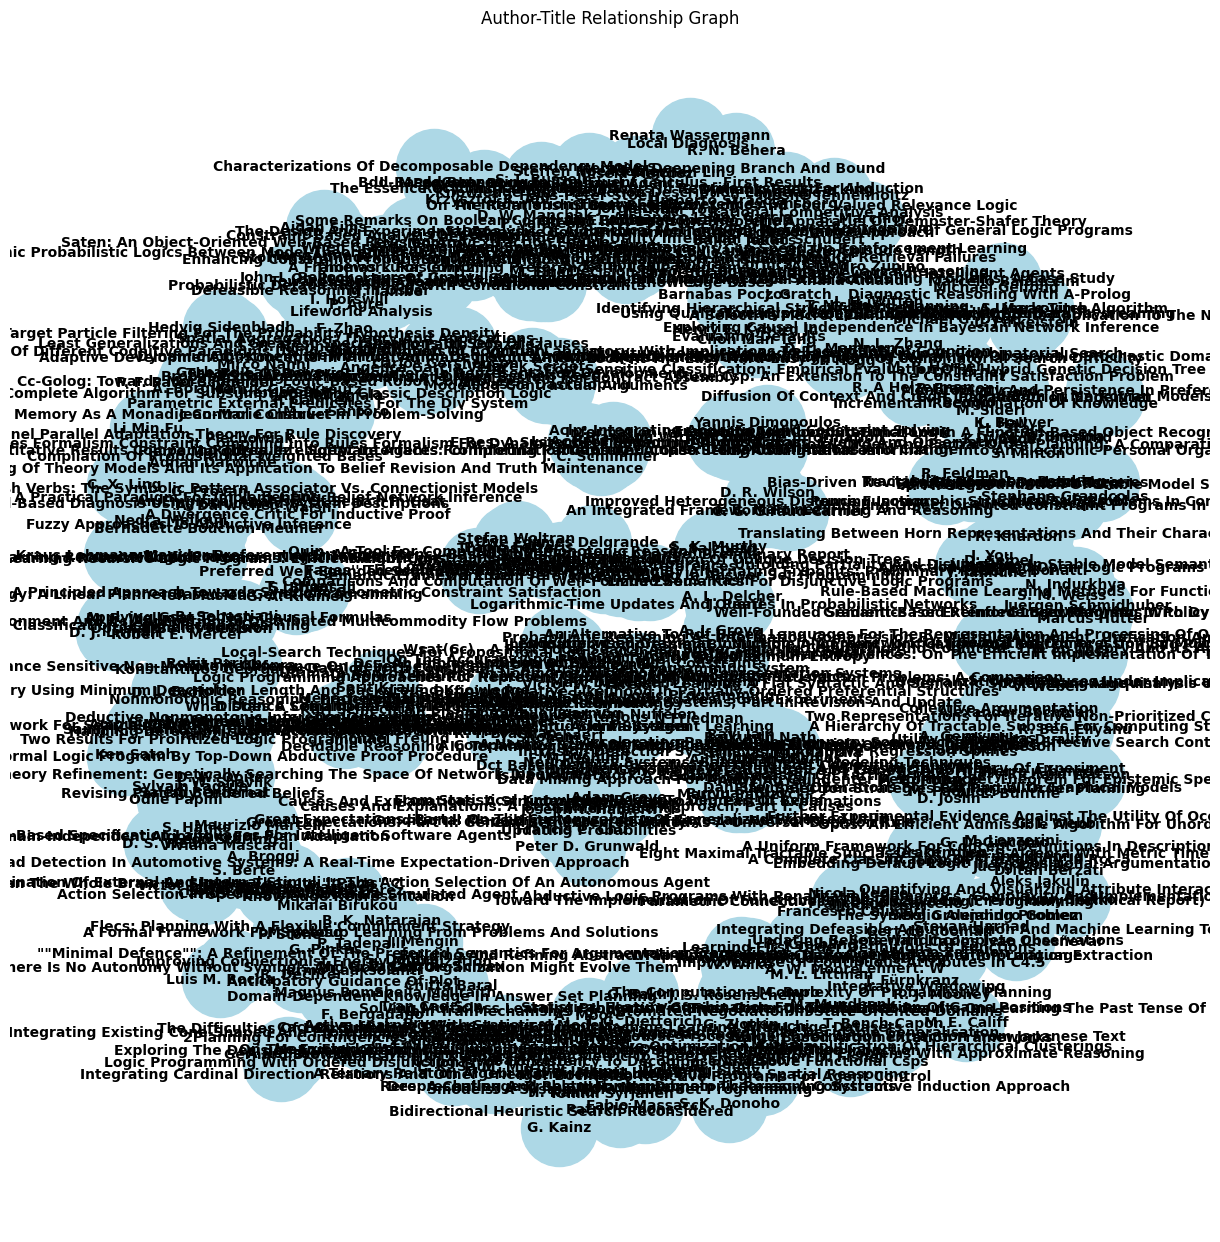

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import plotly.graph_objects as go

# Step 1: Initialize the graph
G = nx.Graph()

# Step 2: Add nodes and edges (author-title relationships)
# Iterate through the rows of the dataframe to create author-title relationships
for _, row in df.iterrows():
    authors = row['authors']

    # Ensure that 'authors' is a valid string and not NaN or other invalid values
    if isinstance(authors, str):
        authors = authors.split(",")  # Assuming authors are separated by commas
        title = row['cleaned_title']

        # Add nodes for the title and the authors
        G.add_node(title, type='title')  # Mark the node as a title
        for author in authors:
            author = author.strip()  # Clean up author names
            G.add_node(author, type='author')  # Mark the node as an author
            G.add_edge(author, title)  # Add an edge between the author and the title

# Step 3: Plot the graph using Matplotlib (static visualization)
plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G, seed=42)  # Using spring layout for node positioning
nx.draw(G, pos, with_labels=True, node_size=3000, node_color='lightblue', font_size=10, font_weight='bold', edge_color='gray')
plt.title('Author-Title Relationship Graph')
plt.show()

# Step 4: Interactive Visualization using Plotly
# Extracting nodes and edges for Plotly visualization
nodes = list(G.nodes())
edges = list(G.edges())

# Create node positions for Plotly visualization
edge_x = []
edge_y = []
for edge in edges:
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    edge_x.append(x0)
    edge_y.append(y0)
    edge_x.append(x1)
    edge_y.append(y1)

# Create nodes for Plotly visualization
node_x = []
node_y = []
for node in nodes:
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)

# Create the plotly graph
edge_trace = go.Scatter(
    x=edge_x, y=edge_y,
    line=dict(width=1, color='#888'),
    hoverinfo='none',
    mode='lines'
)

# Create the node trace
node_trace = go.Scatter(
    x=node_x, y=node_y,
    mode='markers',
    hoverinfo='text',
    marker=dict(
        showscale=True,
        colorscale='YlGnBu',
        size=10,
        colorbar=dict(
            thickness=15,
            title='Node Connections',
            xanchor='left',
            titleside='right'
        )
    )
)

# Assign colors to nodes based on their type (author or title)
node_trace.marker.color = ['blue' if G.nodes[node]['type'] == 'author' else 'green' for node in nodes]
node_trace.text = nodes

# Create the figure
fig = go.Figure(data=[edge_trace, node_trace],
                layout=go.Layout(
                    title='Interactive Author-Title Relationship Graph',
                    titlefont_size=16,
                    showlegend=False,
                    hovermode='closest',
                    xaxis=dict(showgrid=False, zeroline=False),
                    yaxis=dict(showgrid=False, zeroline=False)
                ))

# Show the plot
fig.show()